# 3. Exploratory Data Analysis (EDA)

In this notebook, we investigate the feature-engineered dataset `data/car_data.parquet` and attempt to establish which features indeed imply the car's price. We do this by

- Investigating the distribution of the car prices (i.e. the distribution of the `CarPrice` column)
- Investigate the relationships between some of the features and car prices

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/car_data.parquet")
df.head()

,Make,Model,Variant,CarPrice,Year,Reg,BodyType,Miles,EngineVol,Transmission,FuelType,NumOwner,ULEZ,BrandNew,EngineBHP
0,AC,Cobra,NaN,89995.0,2001,X,convertible,14400.0,4.9,manual,petrol,5,False,False,225.0
1,AC,Cobra,NaN,92500.0,2019,T,convertible,650.0,NaN,manual,petrol,<NA>,False,False,NaN
2,AC,Cobra,NaN,109995.0,2000,X,convertible,21600.0,3.5,manual,petrol,3,False,False,NaN
3,AC,Cobra,NaN,124950.0,1989,F,convertible,2750.0,NaN,manual,petrol,<NA>,False,False,NaN
4,AC,Cobra,NaN,124950.0,1989,E,convertible,15142.0,5.0,manual,petrol,<NA>,False,False,NaN


## 3.1. Car Price Distribution

We plot a histogram of all car prices in the dataset using 50 bins.

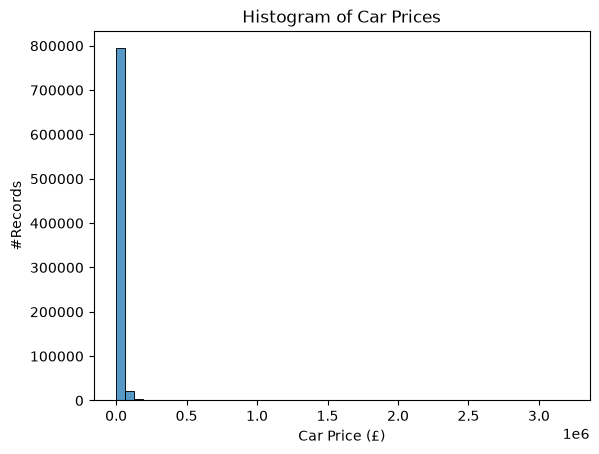

In [3]:
sns.histplot(
    df["CarPrice"],
    bins=50
)

plt.xlabel("Car Price (£)")
plt.ylabel("#Records")
plt.title("Histogram of Car Prices")

plt.show()

This histogram is an extremely interesting result. Almost all of the cars go into the first bin, and there must exist (even if we can't see them) at least one car which is almost £3mil. We investigate this in more detail.

In [4]:
df["CarPrice"].describe()

count    8.184560e+05
mean     2.011859e+04
std      2.224110e+04
min      3.000000e+02
25%      8.990000e+03
50%      1.500000e+04
75%      2.450000e+04
max      3.199830e+06
Name: CarPrice, dtype: float64

We can see that the `CarPrice` column has the following descriptive statistics:

- Mean: £20,118.59
- Lower Quartile: £8,990
- Median: £15,000
- Upper Quartile: £24,500

But the maximum is £3,199,830 which suggests we may have some extreme outliers.

In [5]:
df.nlargest(20, "CarPrice")[
    ["Make", "Model", "Variant", "CarPrice", "Year", "Miles"]
]

,Make,Model,Variant,CarPrice,Year,Miles
167000,Ferrari,Laferrari,NaN,3199830.0,2015,2864.0
421003,McLaren,P1,T V8,2600000.0,2015,329.0
166999,Ferrari,Laferrari,NaN,2200000.0,2013,6198.0
132106,Bugatti,Veyron,NaN,1700000.0,2011,1000.0
166221,Ferrari,250,NaN,1595000.0,1960,44620.0
132105,Bugatti,Veyron,NaN,1450000.0,2008,3800.0
132104,Bugatti,Veyron,NaN,1449900.0,2013,2720.0
590366,Porsche,Carrera Gt,NaN,1400000.0,2004,10834.0
326001,Lamborghini,Reventon,Unlisted,1399950.0,2010,1125.0
589717,Porsche,918,NaN,1350000.0,2015,3209.0


In [6]:
df.nlargest(100, "CarPrice")["Make"].value_counts()

Make
Ferrari          41
Aston Martin     17
McLaren          11
Lamborghini       8
Bugatti           6
Porsche           5
Mercedes-Benz     5
Ford              3
Lexus             2
Rolls-Royce       2
Name: count, dtype: int64

The upper tail of the distribution is dominated by luxury manufacturers. Hence, these represent distributional outliers, rather than data outliers/misentries.

### 3.1.1. Distribution of "Cheaper" Prices

We plot the distribution of cars cheaper than £100,000, as a histogram with 50 bins.

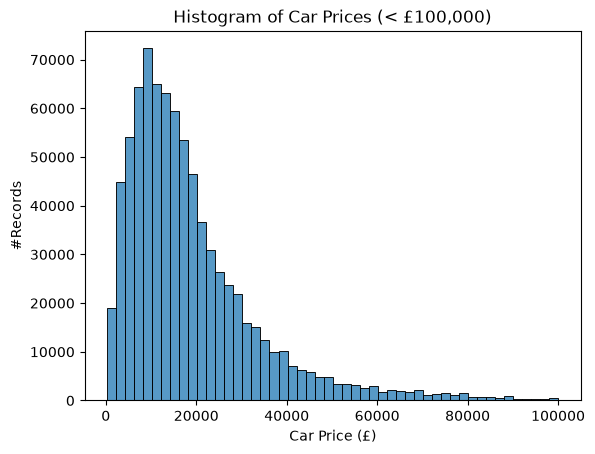

In [7]:
cheaper_cars = df[df["CarPrice"] < 100_000]

sns.histplot(
    cheaper_cars["CarPrice"],
    bins=50
)

plt.xlabel("Car Price (£)")
plt.ylabel("#Records")
plt.title("Histogram of Car Prices (< £100,000)")

plt.show()

In [8]:
cheaper_cars["CarPrice"].describe()

count    811730.000000
mean      18903.736393
std       14919.662871
min         300.000000
25%        8975.000000
50%       14995.000000
75%       24080.000000
max       99999.000000
Name: CarPrice, dtype: float64

In [9]:
cheaper_cars["CarPrice"].skew()

np.float64(1.8823977481869263)

The `CarPrice` column for cheaper cars (< £100,000) is strongly right-skewed (skewness $\approx$ 1.8824). It has a median of £14,995 compared to a mean of £18,903.74. Hence, the distribution has a long upper tail which contains a (relatively) small number of high-value vehicles.

## 3.2. Relationship Between Variables and `CarPrice`

In this section, we investigate the relationship between some of the variables in the dataset and `CarPrice`.

### 3.2.1. Continuous Variables

#### `EngineBHP`

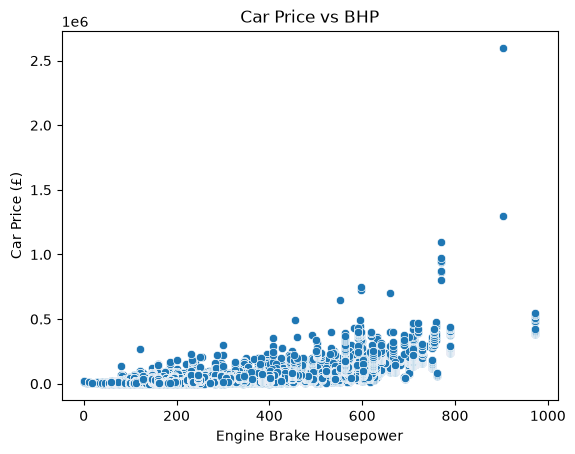

In [10]:
sns.scatterplot(
    data=df,
    x="EngineBHP",
    y="CarPrice"
)

plt.xlabel("Engine Brake Housepower")
plt.ylabel("Car Price (£)")
plt.title("Car Price vs BHP")

plt.show()

In [11]:
# Pearson Coefficient
df[["EngineBHP", "CarPrice"]].corr(method="pearson")

,EngineBHP,CarPrice
EngineBHP,1.000000,0.691729
CarPrice,0.691729,1.000000


In [12]:
# Spearman Coefficient
df[["EngineBHP", "CarPrice"]].corr(method="spearman")

,EngineBHP,CarPrice
EngineBHP,1.000000,0.563914
CarPrice,0.563914,1.000000


`EngineBHP` and `CarPrice` exhibit a Pearson coefficient of 0.6917 which suggests a moderately strong positive linear correlation between engine power and car price. However, they exhibit a weaker Spearman coefficient of 0.5639 which suggests that the strength of the relationship is less consistent when considering the rank ordering of variables. This suggests that `EngineBHP`is a promising feature for `CarPrice` modelling.

#### `Year`

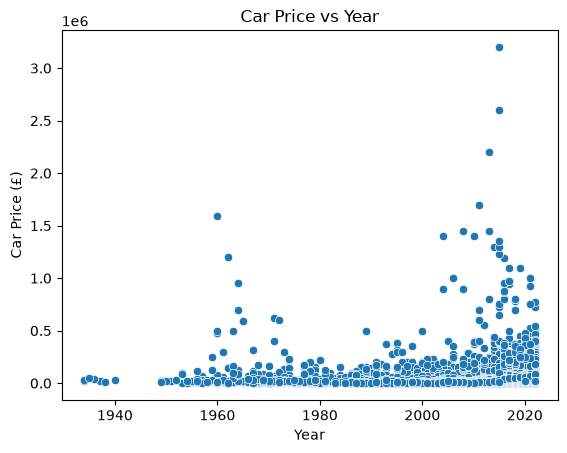

In [13]:
sns.scatterplot(
    data=df,
    x="Year",
    y="CarPrice"
)

plt.xlabel("Year")
plt.ylabel("Car Price (£)")
plt.title("Car Price vs Year")

plt.show()

In [14]:
# Pearson Coefficient
df[["Year", "CarPrice"]].corr(method="pearson")

,Year,CarPrice
Year,1.000000,0.358353
CarPrice,0.358353,1.000000


In [15]:
# Spearman Coefficient
df[["Year", "CarPrice"]].corr(method="spearman")

,Year,CarPrice
Year,1.000000,0.738473
CarPrice,0.738473,1.000000


`Year` and `CarPrice` exhibit a Pearson coefficent of 0.3584 which suggests a weak positive _linear_ correlation between year and car price. However, they exhibit a Spearman coefficient of 0.7385 which suggests a strong positive monotone correlation. This means that whilst the variables have a strong positive correlation, this correlation is unlikely to be linear.

From the graph, we can see the positive correlation by eye. However, the increase towards the end of the graph certainly does not look linear. The scatter diagram also includes "columns" in the graph (i.e. dots extending vertically from the cluster at the bottom) which are likely to be related to popular classic cars pre-2000, and luxury super cars post-2000.

Nonetheless, this suggests that `Year` is a promising feature for modelling `CarPrice`

#### `Miles`

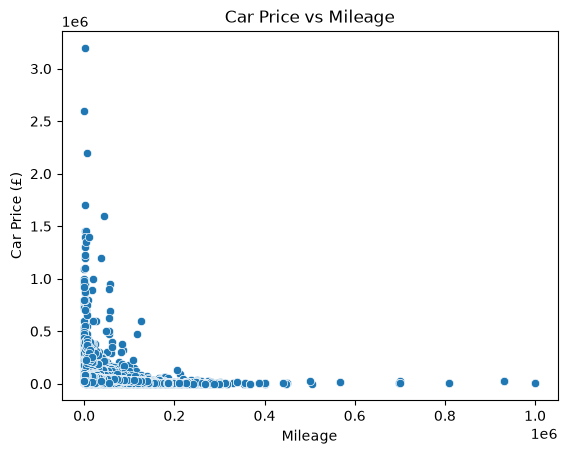

In [16]:
sns.scatterplot(
    data=df,
    x="Miles",
    y="CarPrice"
)

plt.xlabel("Mileage")
plt.ylabel("Car Price (£)")
plt.title("Car Price vs Mileage")

plt.show()

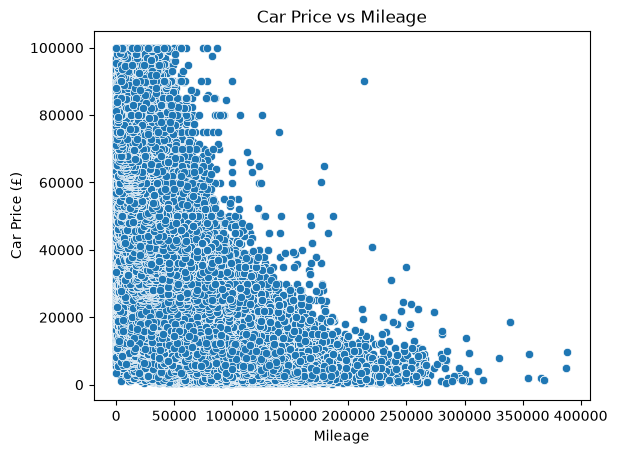

In [17]:
sns.scatterplot(
    data=df[
        (df["CarPrice"] < 100_000)
        & (df["Miles"] < 0.4 * 1e6)
    ],
    x="Miles",
    y="CarPrice"
)

plt.xlabel("Mileage")
plt.ylabel("Car Price (£)")
plt.title("Car Price vs Mileage")

plt.show()

In [18]:
df[["CarPrice", "Miles"]].corr(method="pearson")

,CarPrice,Miles
CarPrice,1.000000,-0.371209
Miles,-0.371209,1.000000


In [19]:
df[["CarPrice", "Miles"]].corr(method="spearman")

,CarPrice,Miles
CarPrice,1.000000,-0.638564
Miles,-0.638564,1.000000


`CarPrice` and `Miles` exhibit a Spearman coefficient of -0.6386 which suggests a strong, monotone, negative correlation between the variables. They exhibit a weaker Pearson coefficient of -0.3712 which suggests that the negative correlation between the two variables is unlikely to be linear. Nonetheless, this suggests that `Miles` is a promising feature for predicting `CarPrice`.

In [20]:
(df["Miles"].isna()).mean()

np.float64(0.0668979150986736)

In [21]:
df.groupby(df["Miles"].isna())["CarPrice"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
Miles,,,
False,763703,14252.0,18993.155181
True,54753,30250.0,35816.264387


6.69% of records do not have a recorded mileage, these cars have a median price which is almost double the median price of the cars which do have a recorded mileage. Therefore, missing mileage data can be used as an indicator of price.

#### `NumOwner`

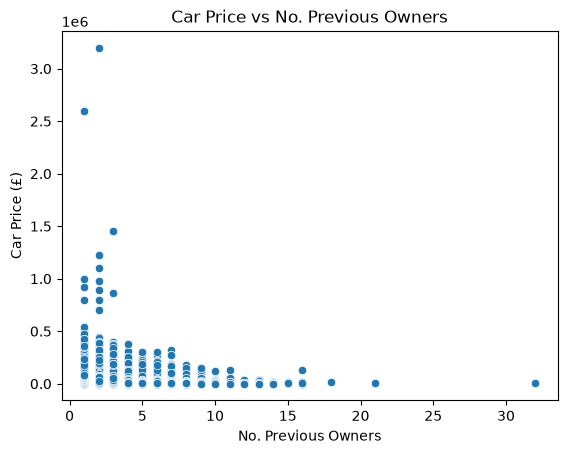

In [22]:
sns.scatterplot(
    data=df,
    x="NumOwner",
    y="CarPrice"
)

plt.xlabel("No. Previous Owners")
plt.ylabel("Car Price (£)")
plt.title("Car Price vs No. Previous Owners")

plt.show()

In [23]:
df[["CarPrice", "NumOwner"]].corr(method="pearson")

,CarPrice,NumOwner
CarPrice,1.000000,-0.218316
NumOwner,-0.218316,1.000000


In [24]:
df[["CarPrice", "NumOwner"]].corr(method="spearman")

,CarPrice,NumOwner
CarPrice,1.000000,-0.449545
NumOwner,-0.449545,1.000000


In [25]:
(~df["NumOwner"].isna()).mean()

np.float64(0.540769448815819)

There is a clear negative correlation between `NumOwner` and `CarPrice` (Spearman = -0.4495), but this correlation is only weakly linear (Pearson = -0.2183). However, we are hesitant to view this feature as promising since only 54% of observations in the dataset have a value in the `NumOwner` column which may diminish the usefulness of this column as a feature.

We investigate if not having a value is some indication of price, compared to having a value.

In [26]:
df.groupby(df["NumOwner"].isna())["CarPrice"].agg(
    ["count", "median", "mean"]
)

,count,median,mean
NumOwner,,,
False,442596,13495.0,18130.484031
True,375860,17000.0,22459.686599


The median price of cars which **do** have a value in the `NumOwner` column is 26% higher than those which **do not**. We shall retain the `NumOwner` column for now as it is not yet certain whether or not it is essential for `CarPrice` prediction. It is hard to say at this stage if it will be promising.

#### `EngineVol`

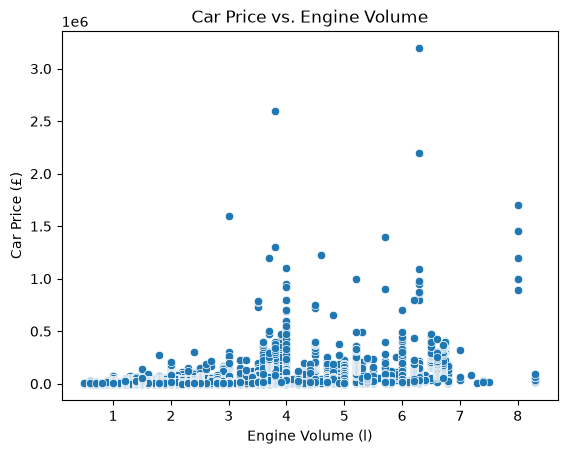

In [27]:
sns.scatterplot(
    data=df,
    x="EngineVol",
    y="CarPrice"
)

plt.xlabel("Engine Volume (l)")
plt.ylabel("Car Price (£)")
plt.title("Car Price vs. Engine Volume")

plt.show()

In [28]:
df[["CarPrice", "EngineVol"]].corr(method="pearson")

,CarPrice,EngineVol
CarPrice,1.000000,0.471217
EngineVol,0.471217,1.000000


In [29]:
df[["CarPrice", "EngineVol"]].corr(method="spearman")

,CarPrice,EngineVol
CarPrice,1.000000,0.314518
EngineVol,0.314518,1.000000


`CarPrice` and `EngineVol` exhibit a moderately strong positive correlation with Pearson coefficient 0.4712. However, they exhibit a Spearman coefficient of 0.3145 which suggests the correlation is partially weaker when considering the rank order of variables. Nonetheless, `EngineVol` may be a promising feature for `CarPrice` modelling.

### 3.2.2. Discrete Variables

#### `BodyType`

In [30]:
body_summary = (
    df.groupby("BodyType")["CarPrice"]
        .agg(["count", "median", "mean"])
        .sort_values("median")
)

body_summary

,count,median,mean
BodyType,,,
hearse,1,3000.0,3000.000000
car derived van,684,5990.0,9344.184211
limousine,39,8295.0,22967.743590
mpv,31774,9999.0,12634.828948
hatchback,269551,10599.0,12466.780973
convertible,32743,13995.0,25089.678527
estate,45308,13999.0,17917.141807
saloon,68613,16287.0,20850.180374
suv,306420,19500.0,24552.229469


Some of the `BodyType` values have few observations. We concentrate on the few with substantial observations.

In [31]:
body_summary = body_summary[body_summary["count"] > 500]
body_summary

,count,median,mean
BodyType,,,
car derived van,684,5990.0,9344.184211
mpv,31774,9999.0,12634.828948
hatchback,269551,10599.0,12466.780973
convertible,32743,13995.0,25089.678527
estate,45308,13999.0,17917.141807
saloon,68613,16287.0,20850.180374
suv,306420,19500.0,24552.229469
coupe,39361,21475.0,37013.138005
pickup,15828,22597.5,23893.773566


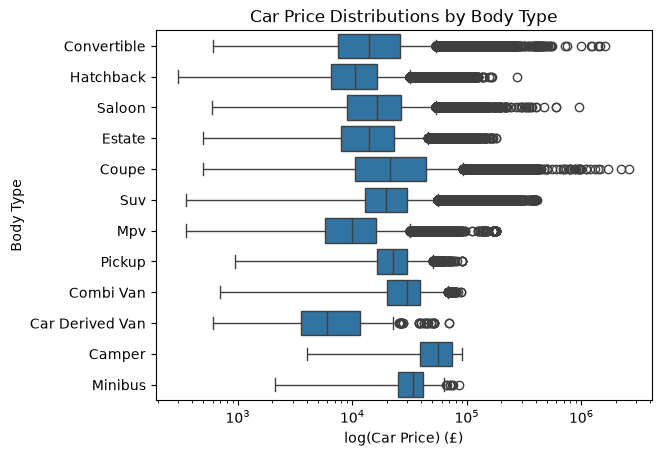

In [32]:
plot_df = df.loc[
    df["BodyType"].isin(body_summary.index),
    ["BodyType", "CarPrice"]
].copy()
plot_df["BodyType"] = plot_df["BodyType"].str.title()

sns.boxplot(
    data=plot_df,
    y="BodyType",
    x="CarPrice"
)

plt.xlabel("log(Car Price) (£)")
plt.ylabel("Body Type")
plt.title("Car Price Distributions by Body Type")

plt.xscale("log")

plt.show()

Medians for `BodyType` groups with substantial observations in the dataset vary between £5,990 for Car Derived Vans and £55,450 for Campers. The box plot reveals visually that `BodyType` indicates substantial differences between the median car prices and this is supported by the numerical data. Thus, `BodyType` is a promising feature for modelling `CarPrice`.

#### `FuelType`

We carry out the same analyses on `FuelType` as `BodyType`.

In [33]:
fuel_summary = (
    df.groupby("FuelType")["CarPrice"]
        .agg(["count", "median", "mean"])
        .sort_values("median")
)

fuel_summary = fuel_summary[fuel_summary["count"] > 500]

fuel_summary

,count,median,mean
FuelType,,,
diesel,325469,13800.0,17656.258753
petrol,419700,14308.0,19387.623126
petrol hybrid,36032,24995.0,28280.299095
electric,13896,32989.0,41376.455815
petrol plug-in hybrid,13715,34995.0,38433.844550
diesel hybrid,8758,45999.0,47876.871203


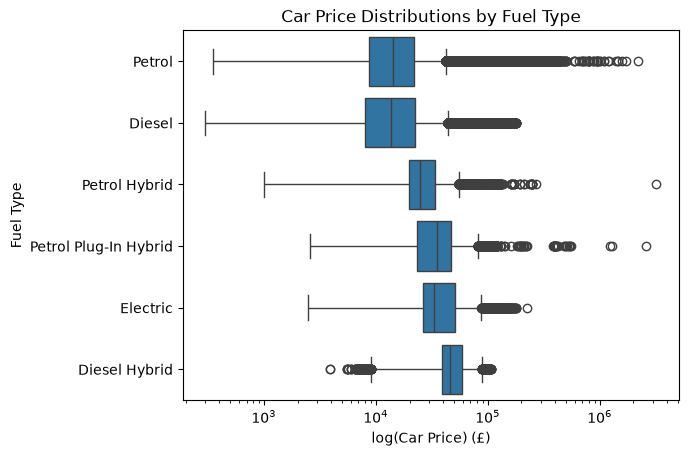

In [34]:
plot_df = df.loc[
    df["FuelType"].isin(fuel_summary.index),
    ["FuelType", "CarPrice"]
].copy()
plot_df["FuelType"] = plot_df["FuelType"].str.title()

sns.boxplot(
    data=plot_df,
    y="FuelType",
    x="CarPrice"
)

plt.xlabel("log(Car Price) (£)")
plt.ylabel("Fuel Type")
plt.title("Car Price Distributions by Fuel Type")

plt.xscale("log")

plt.show()

One can subcategorise the different fuel types into two camps:

1. Conventional types (i.e. Petrol, Diesel)
2. Electric and Hybrid types

Our analysis suggests that `FuelType` alone is insufficient to predict `CarPrice` _within a single camp_. However, the median prices between the camps vary substantially, and we see that electric/hybrid cars exhibit higher prices than conventional fuel types. Therefore, this suggests that `FuelType` is a promising feature for predicting `CarPrice`.

In [35]:
df.columns.values

<ArrowStringArray>
[        'Make',        'Model',      'Variant',     'CarPrice',
         'Year',          'Reg',     'BodyType',        'Miles',
    'EngineVol', 'Transmission',     'FuelType',     'NumOwner',
         'ULEZ',     'BrandNew',    'EngineBHP']
Length: 15, dtype: str

#### `Transmission`

In [36]:
transmission_summary = (
    df.groupby("Transmission")["CarPrice"]
        .agg(["count", "median", "mean"])
        .sort_values("median")
)

transmission_summary

,count,median,mean
Transmission,,,
manual,431215,10998.0,12328.85767
automatic,387028,23000.0,28768.62682


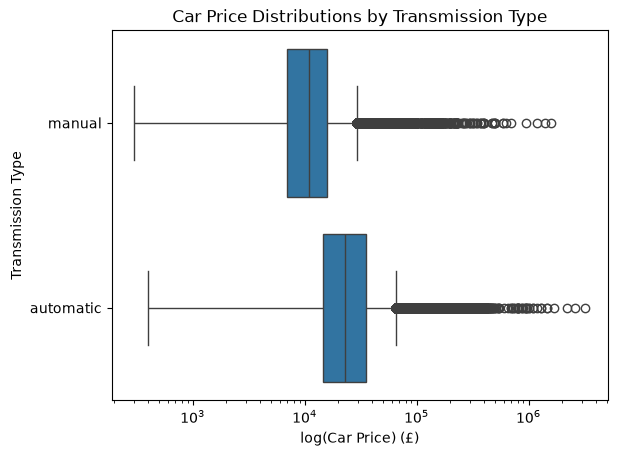

In [37]:
sns.boxplot(
    data=df,
    y="Transmission",
    x="CarPrice"
)

plt.xlabel("log(Car Price) (£)")
plt.ylabel("Transmission Type")
plt.title("Car Price Distributions by Transmission Type")

plt.xscale("log")

plt.show()

The median price of Automatic cars (£23k) is over double the median price of Manual cars (£11k) and the box plot demonstrates that the difference between the distribution of manual and automatic car prices is obvious. Therefore, it is likely that `Transmission` is a promising feature for predicting `CarPrice`.

### 3.2.3. Boolean Variables

We investigate whether the boolean columns could be used to predict `CarPrice`. The analysis we do for each will be the same so we define some helper functions.

In [38]:
def boolean_boxplot(var_name, var_label, title):
    plot_df = df.copy()
    plot_df[var_name] = plot_df[var_name].astype(str)

    sns.boxplot(
        data=plot_df,
        y=var_name,
        x="CarPrice"
    )

    plt.xlabel("log(Car Price) (£)")
    plt.ylabel(var_label)
    plt.title(f"Car Price Distributions depending on {title}")

    plt.xscale("log")

    plt.show()

In [39]:
def boolean_summary(var_name):
    return (
        df.groupby(var_name)["CarPrice"]
            .agg(["count", "median", "mean"])
            .sort_values("median")
    )

In [40]:
df.select_dtypes(bool)

,ULEZ,BrandNew
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
818451,False,False
818452,False,False
818453,False,False
818454,False,False


#### `ULEZ`

In [41]:
boolean_summary("ULEZ")

,count,median,mean
ULEZ,,,
False,151047,7950.0,12308.252021
True,667409,16987.0,21886.209164


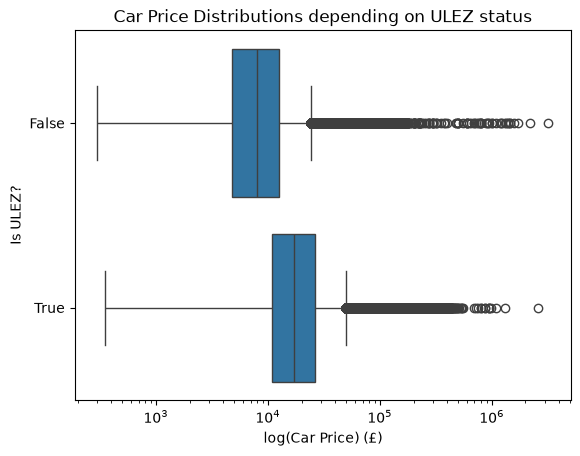

In [42]:
boolean_boxplot("ULEZ", "Is ULEZ?", "ULEZ status")

#### `BrandNew`

In [43]:
boolean_summary("BrandNew")

,count,median,mean
BrandNew,,,
False,764247,14280.0,19000.230433
True,54209,30299.0,35885.340202


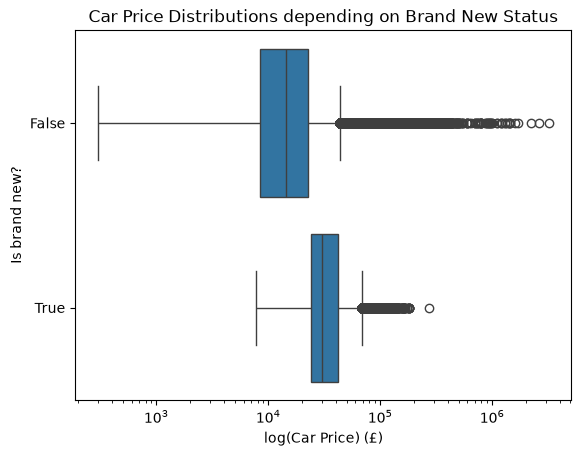

In [44]:
boolean_boxplot("BrandNew", "Is brand new?", "Brand New Status")

`BrandNew` exhibits a substantial association with `CarPrice`. The median price of new cars (£30k) is over double that of not-new cars (£14k) and thus this may be a promising feature to retain for modelling. However, this column is likely just a reflection on how recent the respective `Year` column is.

In [45]:
df.groupby("BrandNew")["Year"].agg(["count", "median", "min", "max"])

,count,median,min,max
BrandNew,,,,
False,764095,2017.0,1934,2022
True,6280,2022.0,2021,2022


"Brand new" cars are all from the years 2021 and 2022, the two latest years available in the dataset. However, non-new cars span 1934-2022. Thus, `BrandNew` is not simply derived from the `Year` column alone and provides extra context as to whether the car is new/used and thus provides more information than age alone. 

## 3.3. Relationships between Variables

The previous section looked at the relationship with the variables with `CarPrice`. In this section, we examine the relationship between the variables themselves.

#### `Year` and `BrandNew`

We covered this in the previous section and during initial analysis. All cars marked as brand new are either from 2021 or 2022, or do not have a year recorded. Cars that are not marked as brand new either do not have a year recorded, or have a year spanning from 1934 to 2022.
Thus we concluded that the `BrandNew` flag indeed provides additional information and context than what `Year` alone provides.

#### `Year` and `ULEZ`

In [46]:
df.groupby("ULEZ")["Year"].agg([
    "count",
    "median",
    "min",
    "max"
])

,count,median,min,max
ULEZ,,,,
False,147397,2012.0,1934,2022
True,622978,2018.0,1960,2022


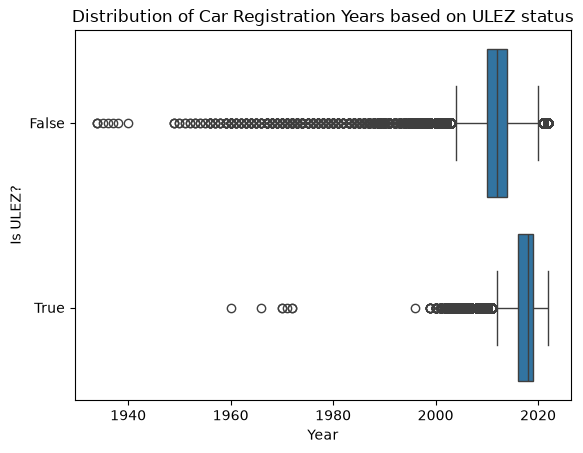

In [47]:
plot_df = df.copy()
plot_df["ULEZ"] = plot_df["ULEZ"].astype(str)

sns.boxplot(
    data=plot_df,
    y="ULEZ",
    x="Year"
)

plt.xlabel("Year")
plt.ylabel("Is ULEZ?")
plt.title(f"Distribution of Car Registration Years based on ULEZ status")

plt.show()

Evidently, ULEZ-compliant cars are substantially newer than those that do not have ULEZ status. Thus, it is possible that our earlier discovery that ULEZ typically implies a higher price may be due to this partial year dependency. However, it is also evident that ULEZ compliancy is not completely dependent on registration year, with the earliest year in the dataset related to a ULEZ-compliant car being 1960. Hence, while the two variables overlap in some information, it is possible that ULEZ still provides additional predictive information.

#### `Year` and `EngineBHP`

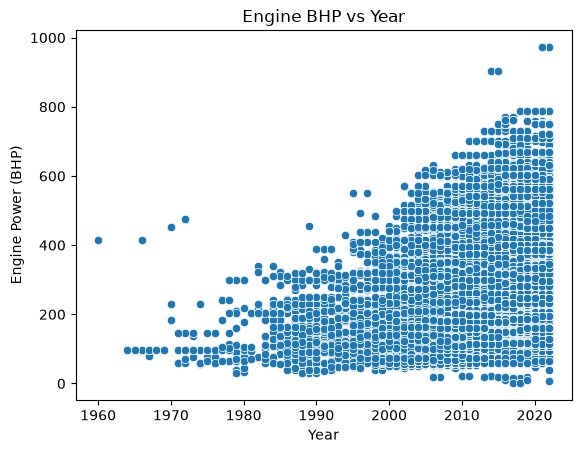

In [48]:
sns.scatterplot(
    data=df,
    x="Year",
    y="EngineBHP"
)

plt.xlabel("Year")
plt.ylabel("Engine Power (BHP)")
plt.title("Engine BHP vs Year")

plt.show()

In [49]:
df[["Year", "EngineBHP"]].corr(method="pearson")

,Year,EngineBHP
Year,1.00000,0.07533
EngineBHP,0.07533,1.00000


In [50]:
df[["Year", "EngineBHP"]].corr(method="spearman")

,Year,EngineBHP
Year,1.000000,0.084635
EngineBHP,0.084635,1.000000


Year and engine power exhibit a very weak positive correlation with Pearson coefficient 0.075 and Spearman coefficient 0.085. This is potentially due to developments in technology over the period captured by the dataset, but this of course cannot be established by the dataset alone. This correlation thus suggests that the respective dataset columns capture substantially different information which may compliment each other during the modelling stage.

#### `Year` and `Miles`

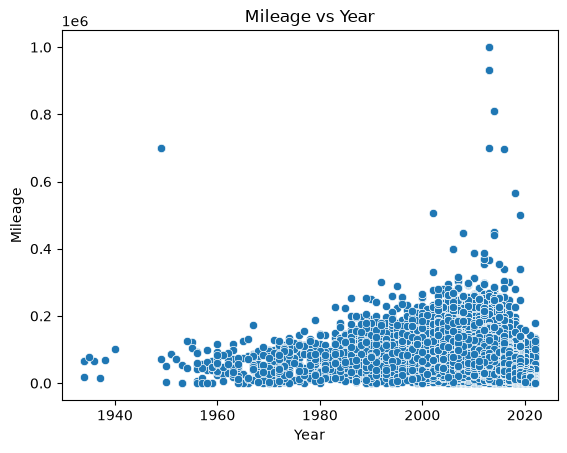

In [51]:
sns.scatterplot(
    data=df,
    x="Year",
    y="Miles"
)

plt.xlabel("Year")
plt.ylabel("Mileage")
plt.title("Mileage vs Year")

plt.show()

In [52]:
df[["Year", "Miles"]].corr(method="pearson")

,Year,Miles
Year,1.00000,-0.68752
Miles,-0.68752,1.00000


In [53]:
df[["Year", "Miles"]].corr(method="spearman")

,Year,Miles
Year,1.000000,-0.804141
Miles,-0.804141,1.000000


In [54]:
df[["Year", "Miles"]].dropna().shape

(763562, 2)

Pearson and Spearman coefficients, -0.688 and -0.804 respectively, suggest a strong negative correlation between Year and Mileage. This indicates that newer vehicles typically have a lower recorded milage. Thus similar to the `ULEZ` column, the `Miles` and `Year` columns have some information overlap. However, as seen by the scatter graph, there are some newer cars with substantial mileage, so this alone is not enough to exclude one column from the modelling phase.

#### `Year` and `FuelType`

In [55]:
df.groupby("FuelType")["Year"].agg([
    "count",
    "median",
    "min",
    "max"
])

,count,median,min,max
FuelType,,,,
bi fuel,203,2020.0,1971,2022
diesel,320859,2016.0,1960,2022
diesel hybrid,6034,2021.0,2012,2022
diesel plug-in hybrid,356,2020.0,2014,2022
electric,10459,2021.0,2010,2022
hydrogen,3,2019.0,2017,2019
petrol,392435,2018.0,1934,2022
petrol hybrid,27694,2021.0,2003,2022
petrol plug-in hybrid,12137,2020.0,2009,2022


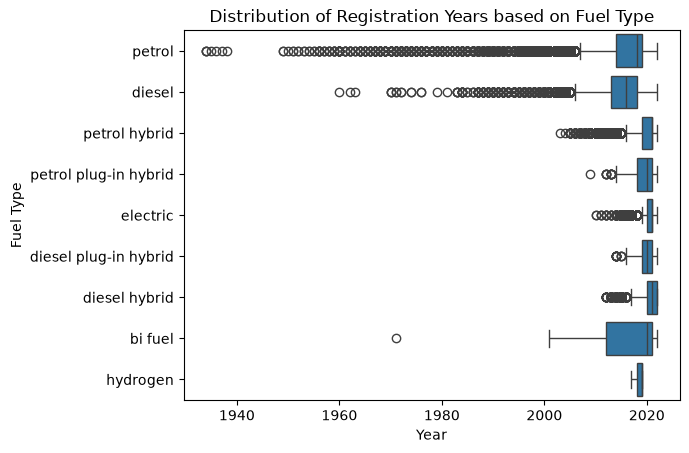

In [56]:
sns.boxplot(
    data=df,
    y="FuelType",
    x="Year"
)

plt.xlabel("Year")
plt.ylabel("Fuel Type")
plt.title(f"Distribution of Registration Years based on Fuel Type")

plt.show()

There is a substantial overlap in `Year` across `FuelType` categories, suggesting that these columns capture different aspects of the cars. However, we note that certain fuel types, particularly hybrid and electric types, are associated with more recent years but this is not sufficient to regard `Year` as a proxy for `FuelType`. Both thus potentially provide complementary information for modelling price.

#### `Year` and `NumOwner`

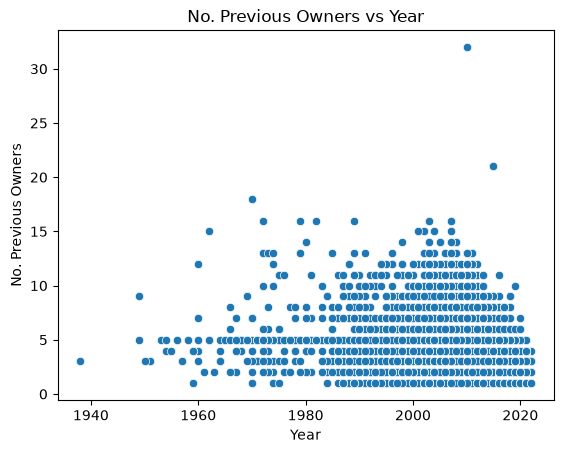

In [57]:
sns.scatterplot(
    data=df,
    x="Year",
    y="NumOwner"
)

plt.xlabel("Year")
plt.ylabel("No. Previous Owners")
plt.title("No. Previous Owners vs Year")

plt.show()

In [58]:
df[["Year", "NumOwner"]].corr(method="pearson")

,Year,NumOwner
Year,1.000000,-0.591291
NumOwner,-0.591291,1.000000


In [59]:
df[["Year", "NumOwner"]].corr(method="spearman")

,Year,NumOwner
Year,1.000000,-0.634223
NumOwner,-0.634223,1.000000


There is a moderate-strong negative correlation between `NumOwner` and `Year` with Pearson coefficient -0.591 and Spearman coefficient -0.634. This indicates that newer cars are associated with a lower number of previous owners. 

## 3.3. Summary

We identified that the dataset is right-skewed.

We investigated the relationship between the dataset variables and `CarPrice` and found that most of them are promising features for prediction. However, we remain unconvinced by `NumOwner` and `BrandNew` and will monitor these as we move to the modelling phase.

We also investigated the relationships between the dataset variables themselves and found that `Miles` and `ULEZ` contain some overlapping information with the `Year` column. Nonetheless, we decided to retain these columns as they capture different aspects of the vehicles in the dataset.